<a href="https://colab.research.google.com/github/arman-hossain45/Deep_Learning_Lab/blob/main/lab_2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [19]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.cifar10.load_data()

In [20]:
x_train.shape

(50000, 32, 32, 3)

In [21]:
y_train.shape

(50000, 1)

In [22]:
x_test.shape

(10000, 32, 32, 3)

In [23]:
y_test.shape

(10000, 1)

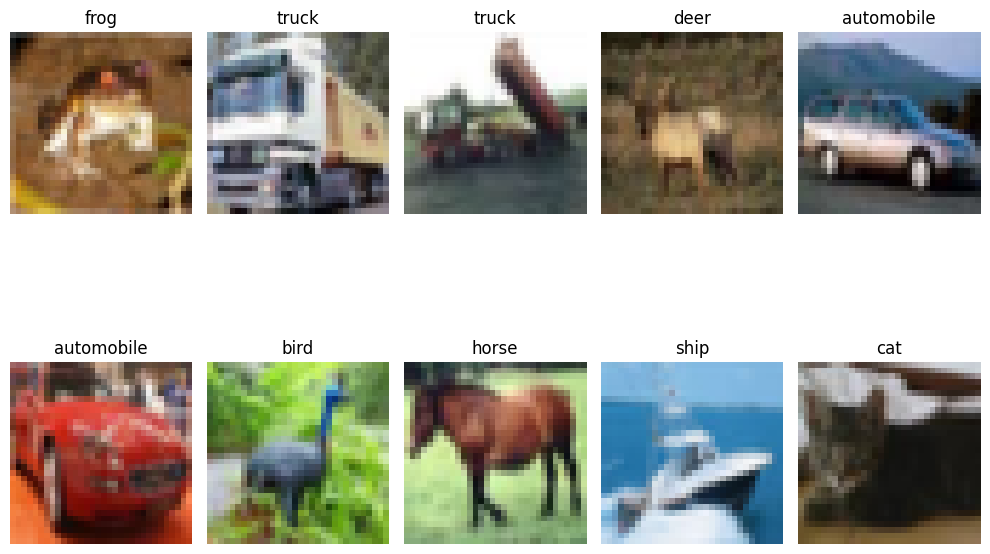

In [24]:
class_names = [
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]

plt.figure(figsize=(10,8))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

In [26]:
from matplotlib.cbook import flatten
model = models.Sequential(
    [
      layers.Conv2D(64, (3,3),activation='relu',padding='same',strides=(1,1),input_shape=(32,32,3)), # 64 is num of kernel which shape is 3*3
      layers.BatchNormalization(),
      layers.MaxPool2D(2,2),
      layers.Dropout(0.25),

      layers.Conv2D(28,(3,3),padding='same',strides=(1,1),activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.25),

      layers.Conv2D(256,(3,3),padding='same',strides=(1,1),activation='relu'),
      layers.MaxPooling2D((2,2)),
      layers.BatchNormalization(),
      layers.Dropout(0.25),

      layers.Flatten(),

      layers.Dense(512,activation='relu'),
      layers.Dropout(0.5),

      layers.Dense(10,activation='softmax')


    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 28)     │        16,156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 28)     │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │        64,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,478,358 (32.34 MB)

 Trainable params: 8,477,662 (32.34 MB)

 Non-trainable params: 696 (2.72 KB)

In [27]:
model.compile(
    optimizer = 'adam',
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

In [28]:
history = model.fit(
    x_train,
    y_train,
    epochs = 5,
    batch_size = 128,
    validation_split = 0.1
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.4184 - loss: 1.7368 - val_accuracy: 0.1934 - val_loss: 7.1333
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5318 - loss: 1.3207 - val_accuracy: 0.4686 - val_loss: 1.7480
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5893 - loss: 1.1640 - val_accuracy: 0.5986 - val_loss: 1.1776
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6336 - loss: 1.0497 - val_accuracy: 0.6408 - val_loss: 1.0122
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6607 - loss: 0.9662 - val_accuracy: 0.6292 - val_loss: 1.0430


In [29]:
test_loss , test_acc = model.evaluate(x_test,y_test)

test_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6178 - loss: 1.0848


0.6177999973297119

In [30]:
test_loss

1.0848053693771362

In [31]:
plt.figure

<function matplotlib.pyplot.figure(num: 'int | str | Figure | SubFigure | None' = None, figsize: 'tuple[float, float] | None' = None, dpi: 'float | None' = None, *, facecolor: 'ColorType | None' = None, edgecolor: 'ColorType | None' = None, frameon: 'bool' = True, FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>, clear: 'bool' = False, **kwargs) -> 'Figure'>